# Recupération de données météo

In [19]:
import openmeteo_requests  # pip install openmeteo-requests

import requests
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from mapflow import animate
from meteofetch import Arome0025, Arpege01, Arome001, Arpege025

In [20]:
! pip install meteofetch

## Données historiques

In [21]:
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": 44.93,
    "longitude": 4.89,
    "start_date": "2020-01-01",
    "end_date": datetime.today().strftime("%Y-%m-%d"),
    "daily": ["temperature_2m_max", "temperature_2m_min", "precipitation_sum",
              "wind_speed_10m_max", "et0_fao_evapotranspiration"],
    "timezone": "Europe/Paris"
}


In [22]:
r = requests.get(url, params=params)
data = r.json()

In [23]:
data

{'latitude': 44.956062,
 'longitude': 4.8837214,
 'generationtime_ms': 20.362257957458496,
 'utc_offset_seconds': 3600,
 'timezone': 'Europe/Paris',
 'timezone_abbreviation': 'GMT+1',
 'elevation': 130.0,
 'daily_units': {'time': 'iso8601',
  'temperature_2m_max': '°C',
  'temperature_2m_min': '°C',
  'precipitation_sum': 'mm',
  'wind_speed_10m_max': 'km/h',
  'et0_fao_evapotranspiration': 'mm'},
 'daily': {'time': ['2020-01-01',
   '2020-01-02',
   '2020-01-03',
   '2020-01-04',
   '2020-01-05',
   '2020-01-06',
   '2020-01-07',
   '2020-01-08',
   '2020-01-09',
   '2020-01-10',
   '2020-01-11',
   '2020-01-12',
   '2020-01-13',
   '2020-01-14',
   '2020-01-15',
   '2020-01-16',
   '2020-01-17',
   '2020-01-18',
   '2020-01-19',
   '2020-01-20',
   '2020-01-21',
   '2020-01-22',
   '2020-01-23',
   '2020-01-24',
   '2020-01-25',
   '2020-01-26',
   '2020-01-27',
   '2020-01-28',
   '2020-01-29',
   '2020-01-30',
   '2020-01-31',
   '2020-02-01',
   '2020-02-02',
   '2020-02-03',
   '

In [26]:
# Représentation des données
df = pd.DataFrame(data["daily"])
df["time"] = pd.to_datetime(df["time"])
df.set_index("time", inplace=True)
print(df.tail())

            temperature_2m_max  ...  et0_fao_evapotranspiration
time                            ...                            
2026-02-17                 8.9  ...                        1.03
2026-02-18                12.4  ...                        1.65
2026-02-19                10.6  ...                        0.99
2026-02-20                 9.9  ...                        1.62
2026-02-21                13.4  ...                        1.69

[5 rows x 5 columns]


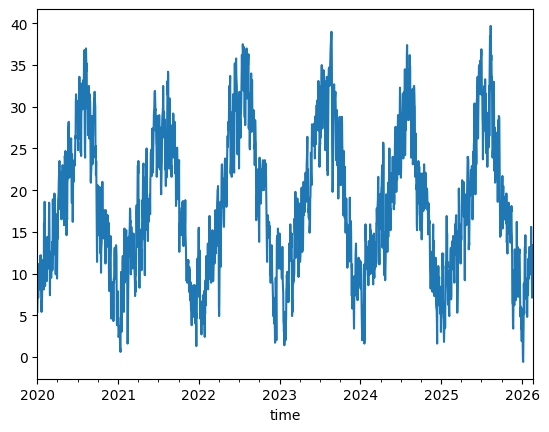

In [27]:
# Graph
df.temperature_2m_max.plot.line(x="time")
plt.show()


## Données prévisionnelles

In [41]:
url = "https://api.open-meteo.com/v1/meteofrance"  # ← archive → forecast

params = {
    "latitude": 44.93,
    "longitude": 4.89,
    "hourly": ["temperature_2m", "temperature_2m", "precipitation",
              "wind_speed_10m", "et0_fao_evapotranspiration"],
    "timezone": "Europe/Paris",
    "forecast_days": 7  # jusqu'à 16
}


In [42]:
r = requests.get(url, params=params)
data = r.json()
data

{'latitude': 44.93,
 'longitude': 4.8899994,
 'generationtime_ms': 5.569338798522949,
 'utc_offset_seconds': 3600,
 'timezone': 'Europe/Paris',
 'timezone_abbreviation': 'GMT+1',
 'elevation': 130.0,
 'hourly_units': {'time': 'iso8601',
  'temperature_2m': '°C',
  'precipitation': 'mm',
  'wind_speed_10m': 'km/h',
  'et0_fao_evapotranspiration': 'mm'},
 'hourly': {'time': ['2026-02-21T00:00',
   '2026-02-21T01:00',
   '2026-02-21T02:00',
   '2026-02-21T03:00',
   '2026-02-21T04:00',
   '2026-02-21T05:00',
   '2026-02-21T06:00',
   '2026-02-21T07:00',
   '2026-02-21T08:00',
   '2026-02-21T09:00',
   '2026-02-21T10:00',
   '2026-02-21T11:00',
   '2026-02-21T12:00',
   '2026-02-21T13:00',
   '2026-02-21T14:00',
   '2026-02-21T15:00',
   '2026-02-21T16:00',
   '2026-02-21T17:00',
   '2026-02-21T18:00',
   '2026-02-21T19:00',
   '2026-02-21T20:00',
   '2026-02-21T21:00',
   '2026-02-21T22:00',
   '2026-02-21T23:00',
   '2026-02-22T00:00',
   '2026-02-22T01:00',
   '2026-02-22T02:00',
   '20

In [47]:
df_forecast = pd.DataFrame(data["hourly"])
df_forecast["time"] = pd.to_datetime(df_forecast["time"])
df_forecast.set_index("time", inplace=True)

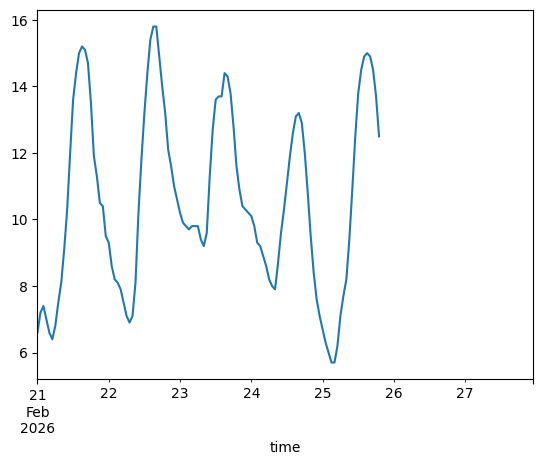

In [48]:
df_forecast.temperature_2m.plot.line(x="time")
plt.show()

## En utilisant les modèles directement

In [49]:
datasets = Arome0025.get_latest_forecast(paquet='SP1', variables=('u10', 'v10'))
datasets['u10']

/home/aurelie/Documents/pro/ARCOOP/01_PROJETS/Projets_Clients/FNE/PestiExpo/Modelisation/.venv/lib/python3.11/site-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)
/home/aurelie/Documents/pro/ARCOOP/01_PROJETS/Projets_Clients/FNE/PestiExpo/Modelisation/.venv/lib/python3.11/site-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warni

<xarray.DataArray 'u10' (time: 52, latitude: 717, longitude: 1121)> Size: 167MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]],
      shape=(52, 717, 1121), dtype=float32)
Coordinates:
  * time               (time) datetime64[ns] 416B 2026-02-21T09:00:00 ... 202...
    step               (time) timedelta64[ns] 416B 00:00:00 ... 2 days 03:00:00
  * latitude           (latitude) float64 6kB 37.5 37.53 37.55 ... 55.38 55.4
  * longitude          (longitude) float64 9kB -12.0 -11.97 ... 15.98 16.0
    heightAboveGround  float64 8B 10.0
    spatial_ref        int64 8B 0
Attributes: (12/31)
    GRIB_paramId:                             165
    GRIB_dataType:                            fc
    GRIB_numberOfPoints:                      803757
    GRIB_typeOfLevel:                         heightAboveGround
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_shortName:                           10u
    GRIB_units:                               m s**-1
    long_name:                                10 metre U wind component
    units:                                    m s**-1
    standard_name:                            eastward_wind
    Packaged by:                              meteofetch

In [ ]:
datasets = Arome0025.get_latest_forecast(paquet='SP2', variables='sp')
datasets['t']

In [7]:
import xarray as xr
import matplotlib.pyplot as plt
from meteofetch import Arpege01

dim = "points"
coords = ["Paris", "Edimbourg"]
x = xr.DataArray([2.33, -3.18], dims=dim)
y = xr.DataArray([48.9, 55.95], dims=dim)

datasets = Arpege01.get_latest_forecast(paquet="SP1", variables="t2m")

/home/aurelie/Documents/pro/ARCOOP/01_PROJETS/Projets_Clients/FNE/PestiExpo/Modelisation/.venv/lib/python3.11/site-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)
/home/aurelie/Documents/pro/ARCOOP/01_PROJETS/Projets_Clients/FNE/PestiExpo/Modelisation/.venv/lib/python3.11/site-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warni

In [26]:
Arpege01.availability()

,SP1,SP2,IP1,IP2,IP3,IP4,HP1,HP2
2026-02-20 18:00:00,False,False,False,False,False,False,False,False
2026-02-20 12:00:00,True,True,True,True,True,True,True,True
2026-02-20 06:00:00,True,True,True,True,True,True,True,True
2026-02-20 00:00:00,True,True,True,True,True,True,True,True
2026-02-19 18:00:00,True,True,True,True,True,True,True,True
2026-02-19 12:00:00,True,True,True,True,True,True,True,True
2026-02-19 06:00:00,True,True,True,True,True,True,True,True
2026-02-19 00:00:00,True,True,True,True,True,True,True,True


/home/aurelie/Documents/pro/ARCOOP/01_PROJETS/Projets_Clients/FNE/PestiExpo/Modelisation/.venv/lib/python3.11/site-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)
/home/aurelie/Documents/pro/ARCOOP/01_PROJETS/Projets_Clients/FNE/PestiExpo/Modelisation/.venv/lib/python3.11/site-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warni

<xarray.DataArray 'v10' (time: 103, latitude: 521, longitude: 741)> Size: 159MB
array([[[-6.41384125e-01, -5.94509125e-01, -5.63259125e-01, ...,
         -1.48513412e+00, -1.11013412e+00, -5.16384125e-01],
        [-6.72634125e-01, -6.41384125e-01, -5.94509125e-01, ...,
         -1.59450912e+00, -1.06325912e+00, -5.16384125e-01],
        [-6.41384125e-01, -6.10134125e-01, -5.94509125e-01, ...,
         -5.94509125e-01, -3.75759125e-01, -1.10134125e-01],
        ...,
        [ 2.43674088e+00,  2.78049088e+00,  2.79611588e+00, ...,
          1.12023659e+01,  1.12336159e+01,  1.12648659e+01],
        [ 4.21115875e-01,  8.11740875e-01,  1.40549088e+00, ...,
          1.13429909e+01,  1.14054909e+01,  1.14211159e+01],
        [-8.28884125e-01, -1.06325912e+00, -1.26638412e+00, ...,
          1.15773659e+01,  1.16086159e+01,  1.16398659e+01]],

       [[-7.10519791e-01, -6.63644791e-01, -6.16769791e-01, ...,
         -1.33551979e+00, -1.06989479e+00, -6.32394791e-01],
        [-7.41769791e-0

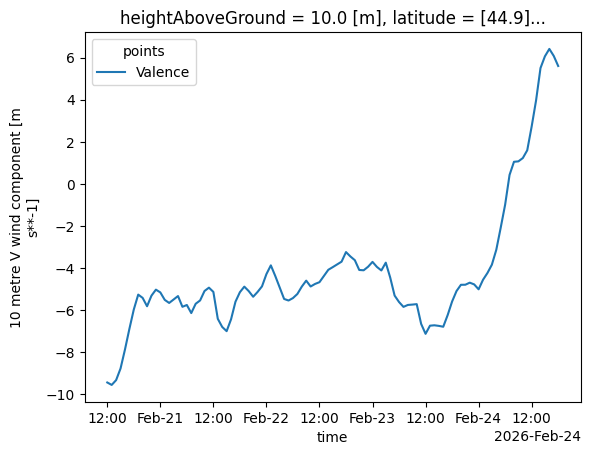

In [22]:
# Récupérer la dernière prévision (paquet SP1 = variables de surface)
datasets = Arpege01.get_latest_forecast(paquet="SP1", variables=["t2m", "u10", "v10"])

# Accéder à la température à 2m
t2m = datasets["v10"]
print(t2m)

# Extraire des points spécifiques (ex: Valence en Drôme)
coords = ["Valence"]
x = xr.DataArray([4.89], dims="points")
y = xr.DataArray([44.93], dims="points")

t2m_local = t2m.sel(longitude=x, latitude=y, method="nearest").assign_coords({"points": coords})
t2m_local.plot.line(x="time")
plt.show()

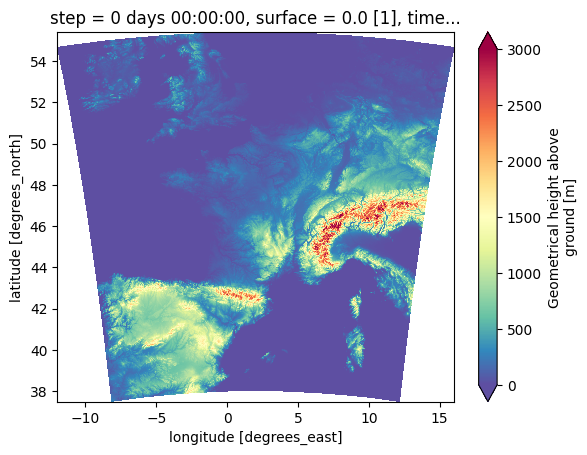

In [ ]:
from meteofetch import Arome001

datasets = Arome001.get_latest_forecast(paquet='SP3', variables='h')

datasets['t2m'].plot(cmap='Spectral_r', vmin=0, vmax=3000)